# SplineTransformer Implementation in Python

Let's implement the Spline concept using Python.<br>
Splines are mathematical functions defined by polynomials, and used to smooth a curve.
Instead of trying to fit one complex equation to your entire dataset, you break the data into segments at points called knots. Each segment gets its own simple polynomial, and they're all stitched together so smoothly you can't even see the seams.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [2]:
# 1. Create some 'wiggly' synthetic data (e.g., seasonal sales)
rng = np.random.RandomState(0)
X = np.sort(rng.rand(100, 1) * 10, axis=0)
y = np.sin(X).ravel() + rng.normal(0, 0.1, X.shape[0])

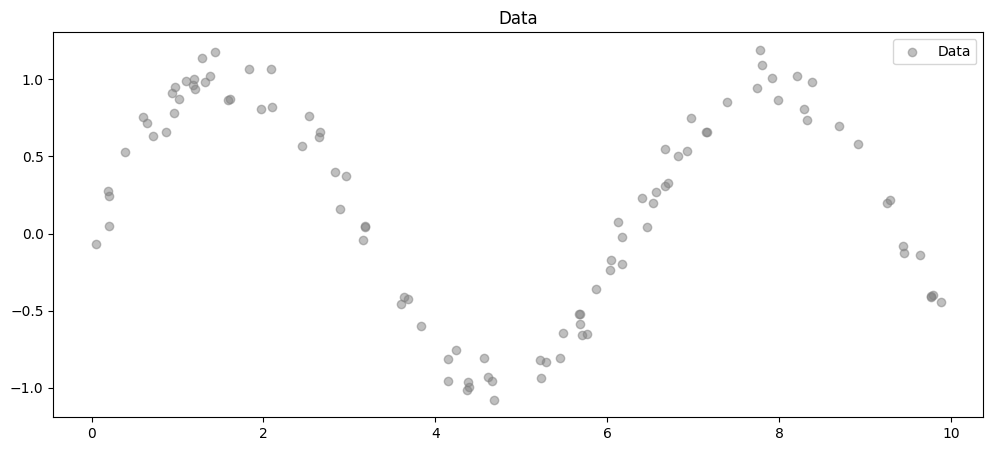

In [3]:
# Plot the data
plt.figure(figsize=(12, 5))
plt.scatter(X, y, color='gray', alpha=0.5, label='Data')
plt.legend()
plt.title("Data")
plt.show()

In [4]:
# 2. Build a pipeline: Splines + Linear Model
# n_knots=5 (default) creates 4 segments; degree=3 makes it a cubic spline
model = make_pipeline(
    SplineTransformer(n_knots=5, degree=3),
    Ridge(alpha=0.1)
    )

# We tune 'n_knots' to find the "Goldilocks" balance
param_grid = {'splinetransformer__n_knots': range(3, 12)}
grid = GridSearchCV(model, param_grid, cv=5)
grid.fit(X, y)

print(f"Best knot count: {grid.best_params_['splinetransformer__n_knots']}")

Best knot count: 8


`SplineTransformer` class breakdown:

* `n_knots`: number of joints in the curve. The more you have, the more flexible the curve gets.
* `degree`: This defines the "smoothness" of the segments. It refers to the degree of the polynomial used between knots (1 is a line; 2 is smoother; 3 is the default).
* `knots`: This one tells the model where to place the joints. For example, uniform separates the curve in equal spaces, while quantile allocates more knots where the data is more dense.
  * Tip: Use *'quantile'* if your data is clustered.
* `extrapolation`: Tells the model what it should do when it encounters data outside the range it saw during training.
  * Tip: use *'periodic'* for cyclic data, such as calendar or clock.
* `include_bias`: Whether to include a "bias" column (a column of all ones). If you are using a LinearRegression or Ridge model later in your pipeline, those models usually have their own fit_intercept=True, so you can often set this to False to avoid redundancy.
* `sparse_output`: Determines how the resulting data is stored in your computer's memory. By default, it is usually False, but switching it to True can be a lifesaver when you're working with massive datasets.

In [6]:
# 2. Build the optimized Spline
model = make_pipeline(
    SplineTransformer(n_knots=8,
                      degree=3,
                      knots= 'uniform',
                      extrapolation='constant',
                      include_bias=False),
    Ridge(alpha=0.1)
    ).fit(X, y)

### Training a high degree polynomial to compare

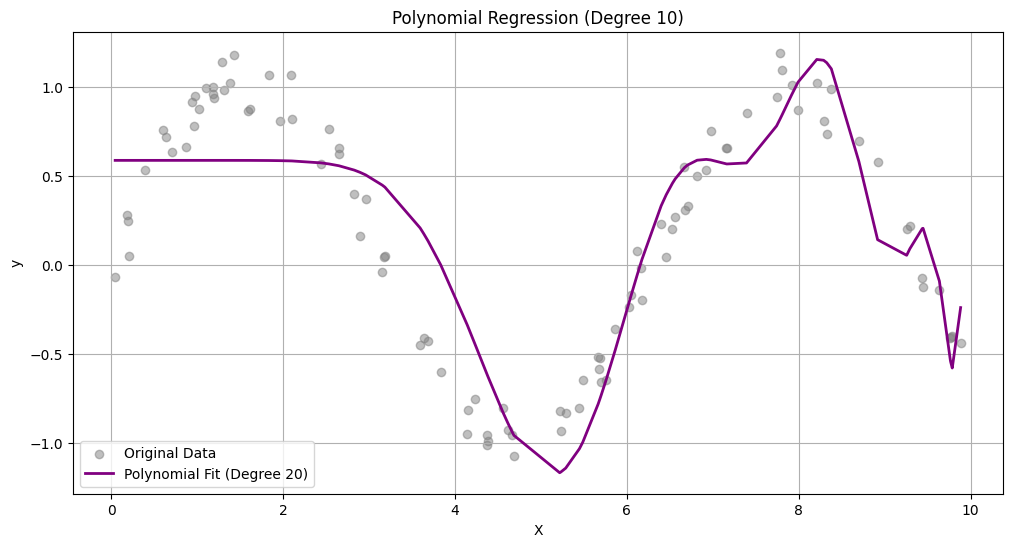

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Create polynomial features of degree 10
poly_features_10 = PolynomialFeatures(degree=20, include_bias=False)
X_poly_10 = poly_features_10.fit_transform(X)

# Fit Linear Regression model
model_10 = LinearRegression()
model_10.fit(X_poly_10, y)

# Prepare data for plotting the fitted curve
X_plot_poly_10 = poly_features_10.transform(X)
y_plot_10 = model_10.predict(X_plot_poly_10)

# Plot the results
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Original Data')
plt.plot(X, y_plot_10, color='purple', linewidth=2, label='Polynomial Fit (Degree 20)')
plt.title('Polynomial Regression (Degree 10)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### Comparing the Results

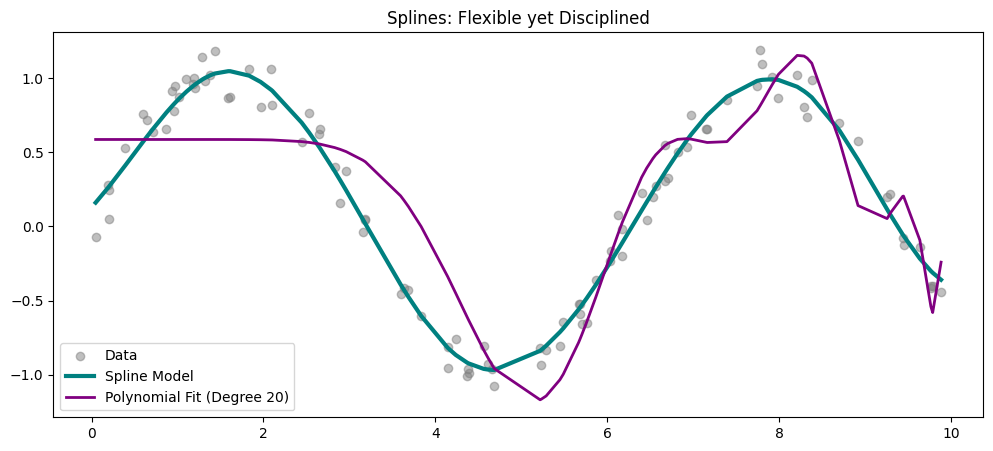

In [8]:
# 3. Predict and Visualize
y_plot = model.predict(X)

# Plot
plt.figure(figsize=(12, 5))
plt.scatter(X, y, color='gray', alpha=0.5, label='Data')
plt.plot(X, y_plot, color='teal', linewidth=3, label='Spline Model')
plt.plot(X, y_plot_10, color='purple', linewidth=2, label='Polynomial Fit (Degree 20)')
plt.legend()
plt.title("Splines: Flexible yet Disciplined")
plt.show()

In [9]:
import numpy as np
from sklearn.preprocessing import SplineTransformer
X = np.arange(6).reshape(6, 1)
X

array([[0],
       [1],
       [2],
       [3],
       [4],
       [5]])

In [11]:
# If include_bias=True, one extra column for Bias is created.
spline = SplineTransformer(degree=2, n_knots=3, include_bias=False)
spline.fit_transform(X)

array([[0.5 , 0.5 , 0.  ],
       [0.18, 0.74, 0.08],
       [0.02, 0.66, 0.32],
       [0.  , 0.32, 0.66],
       [0.  , 0.08, 0.74],
       [0.  , 0.  , 0.5 ]])

In [ ]:
import numpy as np
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

# 1. Generate noisy, non-linear data
rng = np.random.RandomState(42)
X = np.sort(rng.rand(100, 1) * 10, axis=0)
y = np.sin(X).ravel() + rng.normal(0, 0.1, X.shape[0])

# 2. Create a pipeline with placeholders
pipe = make_pipeline(SplineTransformer(), Ridge())

# 3. Define the search space for knots (from 2 to 15)
param_grid = {'splinetransformer__n_knots': range(2, 16)}

# 4. Use Cross-Validation to find the best parameter
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X, y)

best_knots = grid.best_params_['splinetransformer__n_knots']
print(f"The 'Goldilocks' number of knots is: {best_knots}")

The 'Goldilocks' number of knots is: 7


## Low versus High Degree Polynomials

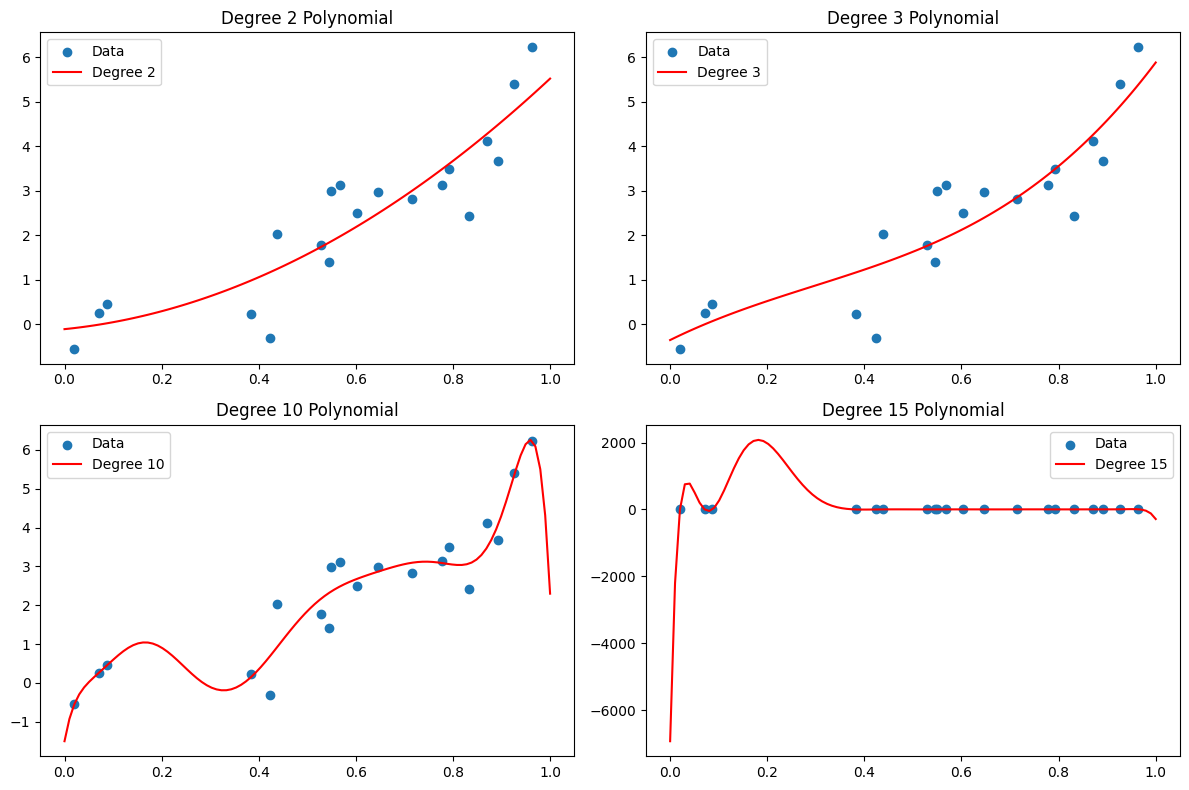

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate some data
np.random.seed(0)
x = np.random.rand(20, 1)
y = 3 * x**2 + 2 * x + np.random.randn(20, 1) / 1.5

# Define degrees
degrees = [2, 3, 10, 15]

# Create a figure
plt.figure(figsize=(12, 8))

# Loop through degrees
for i, degree in enumerate(degrees):
    # Create polynomial features
    poly_features = PolynomialFeatures(degree=degree)
    x_poly = poly_features.fit_transform(x)

    # Fit linear regression
    model = LinearRegression()
    model.fit(x_poly, y)

    # Predict
    x_test = np.linspace(0, 1, 100).reshape(-1, 1)
    x_test_poly = poly_features.transform(x_test)
    y_pred = model.predict(x_test_poly)

    # Plot
    plt.subplot(2, 2, i+1)
    plt.scatter(x, y, label='Data')
    plt.plot(x_test, y_pred, label=f'Degree {degree}', color='red')
    plt.title(f'Degree {degree} Polynomial')
    plt.legend()

plt.tight_layout()
plt.show()

## Time Series Hours

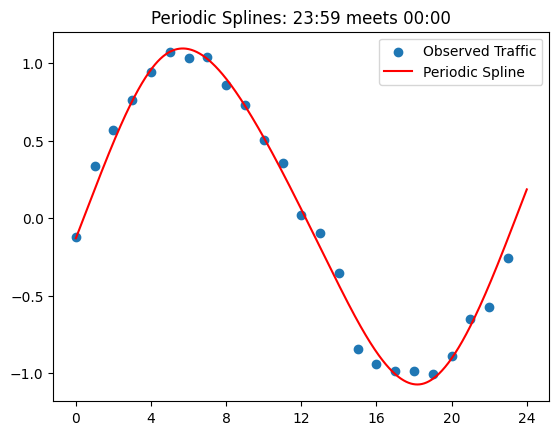

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

# 1. Generate synthetic hourly data (24 hours)
# Imagine this is 'Website Traffic' that peaks at mid-day
hours = np.arange(24).reshape(-1, 1)
traffic = np.sin(2 * np.pi * hours / 24) + np.random.normal(0, 0.1, (24, 1))

# 2. Setup Periodic Splines
# periodic=True ensures the spline 'wraps around'
# knots=[0, 24] defines the start and end of the cycle
spline = SplineTransformer(n_knots=6, degree=3, extrapolation='periodic')
model = make_pipeline(spline, Ridge(alpha=1e-3))
model.fit(hours, traffic)

# 3. Predict for a continuous 24-hour loop
hours_grid = np.linspace(0, 24, 1000).reshape(-1, 1)
predictions = model.predict(hours_grid)

# 4. Visualize the seamless loop
plt.scatter(hours, traffic, label='Observed Traffic')
plt.plot(hours_grid, predictions, color='red', label='Periodic Spline')
plt.xticks(range(0, 25, 4))
plt.legend()
plt.title("Periodic Splines: 23:59 meets 00:00")
plt.show()

## Splines on the Bike Sharing Dataset

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SplineTransformer was fitted with feature names
  warnings.warn(


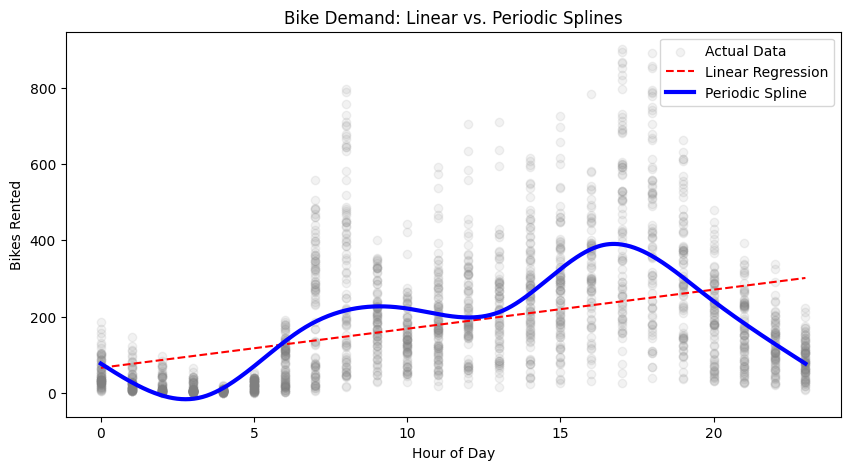

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import Ridge
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline

# 1. Load the real-world Bike Sharing dataset
# We focus on the 'hour' and the target 'count'
data = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True)
df = data.frame.sample(2000, random_state=42).sort_values("hour")
X, y = df[["hour"]], df["count"]

# 2. Linear Model (The "Before" - will likely be a straight, poor-fitting line)
linear_model = Ridge()
linear_model.fit(X, y)

# 3. Spline Model (The "After" - using periodic features for the 24h cycle)
# We manually set knots at 0 and 23 to define the day cycle
spline_model = make_pipeline(
    SplineTransformer(n_knots=8, degree=3, extrapolation="periodic"),
    Ridge()
)
spline_model.fit(X, y)

# 4. Visualize the difference
hours_grid = np.linspace(0, 23, 500).reshape(-1, 1)
plt.figure(figsize=(10, 5))
plt.scatter(X, y, alpha=0.1, color='gray', label='Actual Data')
plt.plot(hours_grid, linear_model.predict(hours_grid), 'r--', label='Linear Regression')
plt.plot(hours_grid, spline_model.predict(hours_grid), 'b-', linewidth=3, label='Periodic Spline')
plt.title("Bike Demand: Linear vs. Periodic Splines")
plt.xlabel("Hour of Day")
plt.ylabel("Bikes Rented")
plt.legend()
plt.show()